In [4]:
from langgraph.store.memory import InMemoryStore
in_memory_store=InMemoryStore()

In [5]:
user_id="1"
namespace_for_memory=(user_id,"memories")

In [6]:
import uuid

memory_id=str(uuid.uuid4())
memory={"user":"你好， 我叫西瓜老师"}
in_memory_store.put(namespace_for_memory,memory_id,memory)

In [7]:
memories=in_memory_store.search(namespace_for_memory)
memories[-1].dict()

{'namespace': ['1', 'memories'],
 'key': '19469798-9f74-4868-a835-01fe3980226b',
 'value': {'user': '你好， 我叫西瓜老师'},
 'created_at': '2026-06-20T09:22:03.554262+00:00',
 'updated_at': '2026-06-20T09:22:03.554262+00:00',
 'score': None}

In [8]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

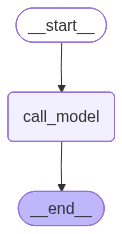

In [9]:
import getpass
import os
from typing import Annotated
from langgraph.graph import MessagesState, StateGraph,START,END
from typing_extensions import TypedDict
from IPython.display import display,Image
from langchain_core.messages import AnyMessage,SystemMessage,HumanMessage,ToolMessage
from langgraph.graph.message import add_messages
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

in_memory_store=InMemoryStore()
memory=MemorySaver()

class State(TypedDict):
    messages:Annotated[list,add_messages]
    
def call_model(state:MessagesState,config:RunnableConfig,*,store:BaseStore):
    
    user_id=config["configurable"]["user_id"]
    
    namespace=("memories",user_id)
    
    memories=store.search(namespace)
    info="\n".join([d.value["data"] for d in memories])
    
    last_message=state["messages"][-1]
    store.put(namespace,str(uuid.uuid4()),{"data":last_message.content})
    
    system_msg=f"Answer the user's question in context: {info}"
    
    response=llm.invoke([{"type":"system","content":system_msg}]+state["messages"])
    
    store.put(namespace,str(uuid.uuid4()),{"data":response.content})
    
    return {"messages":response}

builder=StateGraph(State)

builder.add_node("call_model",call_model)

builder.add_edge(START,"call_model")
builder.add_edge("call_model",END)

graph=builder.compile(checkpointer=memory,store=in_memory_store)

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
config={"configurable":{"thread_id":"10"},"user_id":"1"}

async for chunk in graph.astream({"messages":["你好，我是西瓜老师"]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

你好，我是西瓜老师
================================== Ai Message ==================================

你好！西瓜老师，很高兴认识你！🍉 有什么需要帮忙的吗？无论是学习、生活还是其他问题，都可以随时问我哦～


In [11]:
config ={"configurable":{"thread_id":"10"},"user_id":"1"}

async for chunk in graph.astream({"messages":["你知道我叫什么吗"]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

你知道我叫什么吗
================================== Ai Message ==================================

哈哈，西瓜老师，你刚才自我介绍说“我是西瓜老师”，所以我就叫你“西瓜老师”啦！不过如果你有其他名字或昵称，也可以告诉我哦～ 😄


In [12]:
config ={"configurable":{"thread_id":"11"},"user_id":"1"}

async for chunk in graph.astream({"messages":["你知道我叫什么吗"]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

你知道我叫什么吗
================================== Ai Message ==================================

哈哈，你刚才说“我是西瓜老师”，所以我就记住啦！你叫**西瓜老师**～ 不过如果你还有其他名字或小秘密，也可以悄悄告诉我哦！😄


In [13]:
config ={"configurable":{"thread_id":"12"},"user_id":"3"}

async for chunk in graph.astream({"messages":["你知道我叫什么吗"]},config,stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

你知道我叫什么吗
================================== Ai Message ==================================

抱歉，我不知道你叫什么名字。我们刚刚开始对话，你还没有告诉我你的名字呢。如果你愿意的话，可以告诉我你的名字，这样我就能记住啦！😊


In [16]:
for memory in in_memory_store.search(("memories","1")):
    print(memory.value)

{'data': '你好，我是西瓜老师'}
{'data': '你好！西瓜老师，很高兴认识你！🍉 有什么需要帮忙的吗？无论是学习、生活还是其他问题，都可以随时问我哦～'}
{'data': '你知道我叫什么吗'}
{'data': '哈哈，西瓜老师，你刚才自我介绍说“我是西瓜老师”，所以我就叫你“西瓜老师”啦！不过如果你有其他名字或昵称，也可以告诉我哦～ 😄'}
{'data': '你知道我叫什么吗'}
{'data': '哈哈，你刚才说“我是西瓜老师”，所以我就记住啦！你叫**西瓜老师**～ 不过如果你还有其他名字或小秘密，也可以悄悄告诉我哦！😄'}
